# 3. Non-normality and transformations

The **purpose** is to visualize the relationship between data and a statistical test, not to focus on the code.

Follow the workbook to the end and only then change the code.

This notebook will go over non-normal data and methods to handle it - namely transformations and non-parametric testing.

> **Terms**
>
> - **Normal** — the bell-shaped distribution that the t-test, ANOVA and linear regression all
>   assume for their residuals. Real measurements are often not normal.
> - **Skewed** — one long tail. Very common for anything that cannot go below zero: concentrations,
>   counts, times, cell densities.
> - **Transformation** — re-expressing the data on another scale, most often the log, to make the
>   shape match what the test assumes. This is not cheating: for a quantity that varies
>   multiplicatively, the log scale is the natural one, and a *fold change* becomes a *difference*,
>   which is exactly what these tests compare.
> - **Non-parametric test** — one that uses only the order of the values, not the values
>   themselves, so it makes no assumption about the shape at all.

First we generate two sets of lognormal data and plot it

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



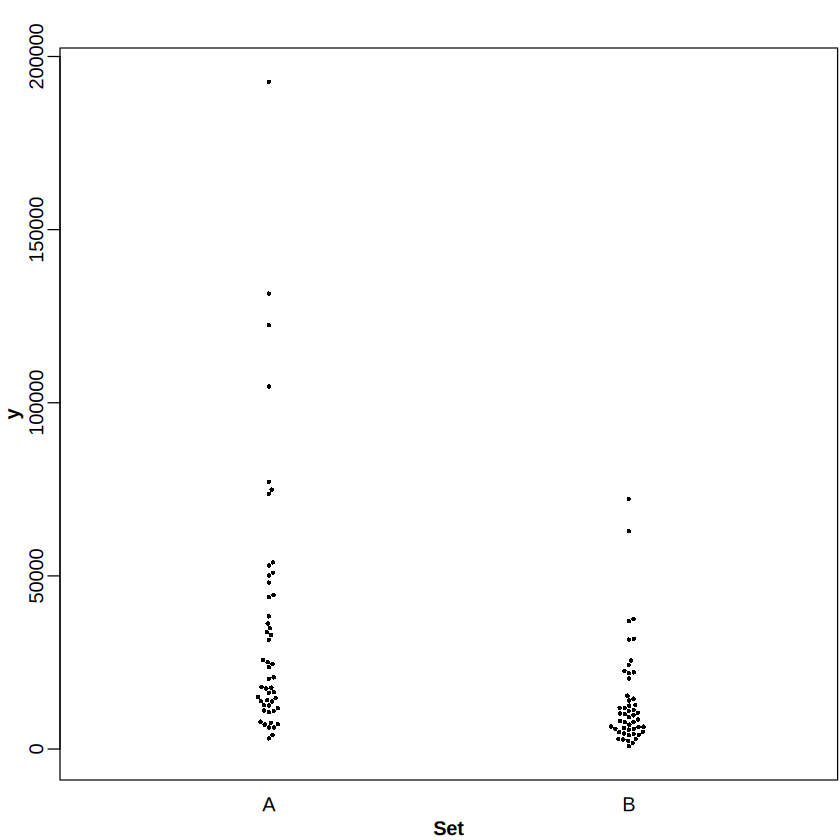

In [1]:
install.packages("beeswarm")
library("beeswarm")
rm(list=ls())
# Set a random seed for reproducibility
set.seed(123)
par(mar=c(2.5,2.5,2,0.1), mgp=c(1.4,0.4,0),font.lab=2,mfrow=c(1,1))

# Generate lognormal data with a specified mean and standard deviation
# "Lognormal" means the LOGARITHM of the data is normal — the data itself is skewed,
# with a long tail to the right. Concentrations, counts and cell densities behave like this.
mu1 <- 10       # Mean of the logarithm of the data
sigma1 <- 1    # Standard deviation of the logarithm of the data
N1 <- 50     # Number of data points to generate

# Generate lognormal data with a specified mean and standard deviation
mu2 <- 9       # Mean of the logarithm of the data — one unit below group A on the log scale
sigma2 <- 1    # Standard deviation of the logarithm of the data
N2 <- 50     # Number of data points to generate


# Generate lognormal data
lognormal_data1 <- rlnorm(N1, meanlog = mu1, sdlog = sigma1)
lognormal_data2 <- rlnorm(N2, meanlog = mu2, sdlog = sigma2)

#store in DF — one column of group labels (X), one of values (Y)
DF=data.frame(X=c(rep("A",N1), rep("B",N2)),Y=c(lognormal_data1,lognormal_data2))

#Plot — note the y axis: a few huge values stretch it, and most points are squashed at the bottom
beeswarm( Y~X,data = DF,pch=16, cex=0.5,
          xlab="Set",ylab="y",mgp = c(1.5, 0.5, 0) ,  font.lab=2 )


A simple t-test will produce a significant p-value, even if the assumptions of normality are not
met. This is what we do **not** do!

Notice what is dangerous about this: nothing fails. There is no warning and no error — just a
p-value that looks like any other, computed from an assumption that is not true.

In [2]:
#run t-test
#This runs, and returns a p-value, and the p-value is not trustworthy — the test assumes
#roughly normal data and these data are anything but. Nothing warns you.
t.test(Y~X,DF)


	Welch Two Sample t-test

data:  Y by X
t = 3.7214, df = 63.308, p-value = 0.0004231
alternative hypothesis: true difference in means between group A and group B is not equal to 0
95 percent confidence interval:
  9706.285 32215.322
sample estimates:
mean in group A mean in group B 
       34902.37        13941.57 


A better approach is to log-transform the data, ensure that it looks normal, and only then do the
t-test.


	Welch Two Sample t-test

data:  logY by X
t = 4.8486, df = 97.951, p-value = 4.675e-06
alternative hypothesis: true difference in means between group A and group B is not equal to 0
95 percent confidence interval:
 0.2278098 0.5434931
sample estimates:
mean in group A mean in group B 
       4.357886        3.972235 


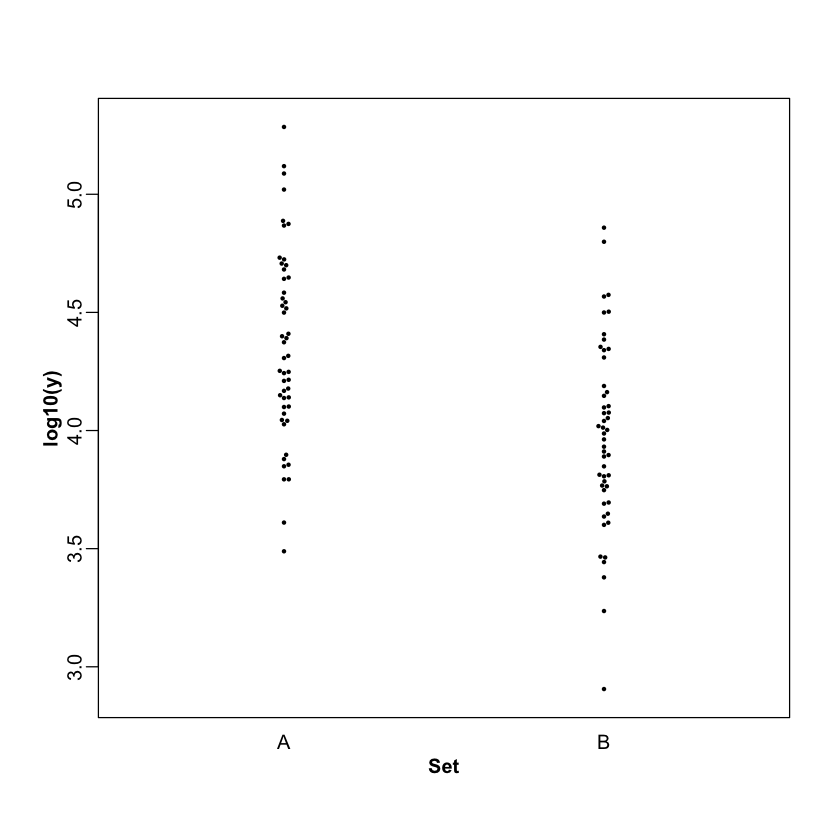

In [3]:
#Try with logtransform
DF$logY=log10(DF$Y)          # a new column holding the log10 of every value

beeswarm( logY~X,data = DF,pch=16, cex=0.5,
          xlab="Set",ylab="log10(y)",mgp = c(1.5, 0.5, 0) ,  font.lab=2 )

#run t-test — now on data whose shape actually matches what the test assumes
t.test(logY~X,DF)

### Checking, rather than hoping

"Ensure that it looks normal" needs an actual check. Two ways, and you should use both — the picture
tells you *how* it deviates, the test tells you *whether* it does.

raw:        p = 9.38e-14 


log10:      p = 0.979 


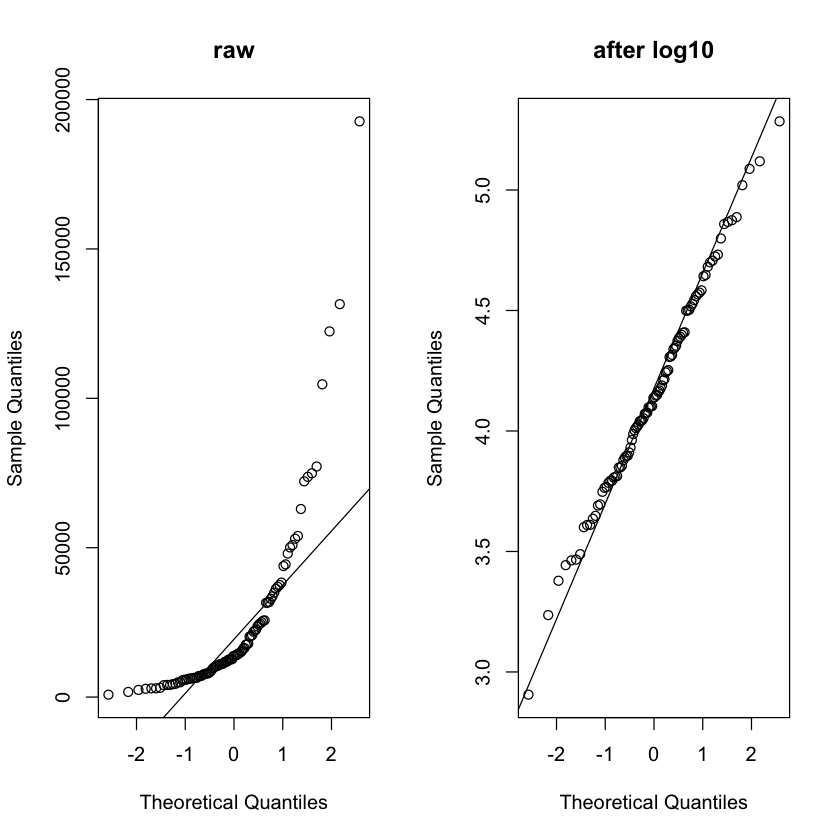

In [4]:
# Look before you leap: a Q-Q plot puts your data against what normal data would look like.
# Points on the straight line = normal. A curve away from it = not normal.
par(mfrow=c(1,2))
qqnorm(DF$Y,     main="raw");          qqline(DF$Y)
qqnorm(DF$logY,  main="after log10");  qqline(DF$logY)
par(mfrow=c(1,1))

# Shapiro-Wilk puts a number on it. A SMALL p-value is evidence AGAINST normality.
cat("raw:        p =", format(shapiro.test(DF$Y)$p.value,    digits=3), "\n")
cat("log10:      p =", format(shapiro.test(DF$logY)$p.value, digits=3), "\n")

Alternatively, we can use a non-parametric test on the untransformed data

In [5]:
#run wilcoxons test
#Compares ranks rather than values, so the shape of the distribution does not matter
#and no transformation is needed.
wilcox.test(Y~X,DF)


	Wilcoxon rank sum test with continuity correction

data:  Y by X
W = 1897, p-value = 8.317e-06
alternative hypothesis: true location shift is not equal to 0


**Question 3.1** What are the pros and cons of transforming versus using non-parametric tests?

**Question 3.3** Compare the two p-values from the log-transformed t-test and the Wilcoxon test.
Do they agree? Would they still agree if the two groups had different spreads as well as different
means?

**Question 3.4** The t-test on `logY` compares the mean of the logs. Back on the original scale,
that is the **geometric** mean, not the arithmetic one — and the difference between two log means is
the log of a **ratio**. So what is that test actually claiming about A and B: that they differ by an
amount, or by a factor?

**Question 3.2** What are the non-parametric equivalents of the ANOVA and linear regression??